In [1]:
!pip -q install mlxtend

In [13]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client.session"
)

import warnings
warnings.simplefilter("ignore", DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [14]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [15]:
transactions = [

    ["Veg Biryani","Raita","Coke"],
    ["Veg Biryani","Raita"],
    ["Veg Biryani","Masala Papad","Coke"],
    ["Veg Biryani","Raita","Masala Papad"],
    ["Chicken Biryani","Coke"],
    ["Chicken Biryani","Raita"],
    ["Pizza","Garlic Bread","Pepsi"],
    ["Pizza","Garlic Bread"],
    ["Burger","Fries","Coke"],
    ["Burger","Fries"],
    ["Burger","Coke"],
    ["Veg Biryani","Coke"],
    ["Veg Biryani","Raita","Coke","Masala Papad"],
    ["Pizza","Pepsi"],
    ["Chicken Biryani","Coke","Raita"],
    ["Burger","Fries","Pepsi"],
    ["Veg Biryani","Raita","Coke"],
    ["Veg Biryani","Raita"],
    ["Pizza","Garlic Bread","Pepsi"],
    ["Burger","Fries"]

]

print("Total Transactions :", len(transactions))

Total Transactions : 20


In [16]:
te = TransactionEncoder()

encoded = te.fit(transactions).transform(transactions)

df = pd.DataFrame(encoded, columns=te.columns_)

df.head()

,Burger,Chicken Biryani,Coke,Fries,Garlic Bread,Masala Papad,Pepsi,Pizza,Raita,Veg Biryani
0,False,False,True,False,False,False,False,False,True,True
1,False,False,False,False,False,False,False,False,True,True
2,False,False,True,False,False,True,False,False,False,True
3,False,False,False,False,False,True,False,False,True,True
4,False,True,True,False,False,False,False,False,False,False


In [17]:
print(df.shape)

df.head(10)

(20, 10)


,Burger,Chicken Biryani,Coke,Fries,Garlic Bread,Masala Papad,Pepsi,Pizza,Raita,Veg Biryani
0,False,False,True,False,False,False,False,False,True,True
1,False,False,False,False,False,False,False,False,True,True
2,False,False,True,False,False,True,False,False,False,True
3,False,False,False,False,False,True,False,False,True,True
4,False,True,True,False,False,False,False,False,False,False
5,False,True,False,False,False,False,False,False,True,False
6,False,False,False,False,True,False,True,True,False,False
7,False,False,False,False,True,False,False,True,False,False
8,True,False,True,True,False,False,False,False,False,False
9,True,False,False,True,False,False,False,False,False,False


In [18]:
frequent_itemsets = apriori(
    df,
    min_support=0.20,
    use_colnames=True
)

frequent_itemsets.sort_values(
    by="support",
    ascending=False,
    inplace=True
)

frequent_itemsets

,support,itemsets
1,0.45,(Coke)
5,0.40,(Raita)
6,0.40,(Veg Biryani)
10,0.30,"(Raita, Veg Biryani)"
0,0.25,(Burger)
9,0.25,"(Veg Biryani, Coke)"
2,0.20,(Fries)
3,0.20,(Pepsi)
4,0.20,(Pizza)
8,0.20,"(Raita, Coke)"


In [19]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Raita),(Veg Biryani),0.40,0.40,0.30,0.750000,1.875000,1.0,0.14,2.400000,0.777778,0.600000,0.583333,0.750000
1,(Veg Biryani),(Raita),0.40,0.40,0.30,0.750000,1.875000,1.0,0.14,2.400000,0.777778,0.600000,0.583333,0.750000
2,(Veg Biryani),(Coke),0.40,0.45,0.25,0.625000,1.388889,1.0,0.07,1.466667,0.466667,0.416667,0.318182,0.590278
3,(Coke),(Veg Biryani),0.45,0.40,0.25,0.555556,1.388889,1.0,0.07,1.350000,0.509091,0.416667,0.259259,0.590278
4,(Raita),(Coke),0.40,0.45,0.20,0.500000,1.111111,1.0,0.02,1.100000,0.166667,0.307692,0.090909,0.472222
5,(Fries),(Burger),0.20,0.25,0.20,1.000000,4.000000,1.0,0.15,inf,0.937500,0.800000,1.000000,0.900000
6,(Burger),(Fries),0.25,0.20,0.20,0.800000,4.000000,1.0,0.15,4.000000,1.000000,0.800000,0.750000,0.900000


In [20]:
def recommend(item):

    rec = rules[
        rules["antecedents"].apply(lambda x: item in x)
    ]

    rec = rec.sort_values(
        by="confidence",
        ascending=False
    )

    print("="*50)
    print("Customer Ordered :", item)
    print("="*50)

    if len(rec)==0:
        print("No Recommendation")
        return

    for _, row in rec.iterrows():

        items = ", ".join(list(row["consequents"]))

        print(f"\nRecommended : {items}")
        print(f"Support     : {row['support']:.2f}")
        print(f"Confidence  : {row['confidence']:.2f}")
        print(f"Lift        : {row['lift']:.2f}")

In [21]:
recommend("Veg Biryani")

Customer Ordered : Veg Biryani

Recommended : Raita
Support     : 0.30
Confidence  : 0.75
Lift        : 1.87

Recommended : Coke
Support     : 0.25
Confidence  : 0.62
Lift        : 1.39


In [22]:
recommend("Burger")

recommend("Pizza")

recommend("Chicken Biryani")

Customer Ordered : Burger

Recommended : Fries
Support     : 0.20
Confidence  : 0.80
Lift        : 4.00
Customer Ordered : Pizza
No Recommendation
Customer Ordered : Chicken Biryani
No Recommendation


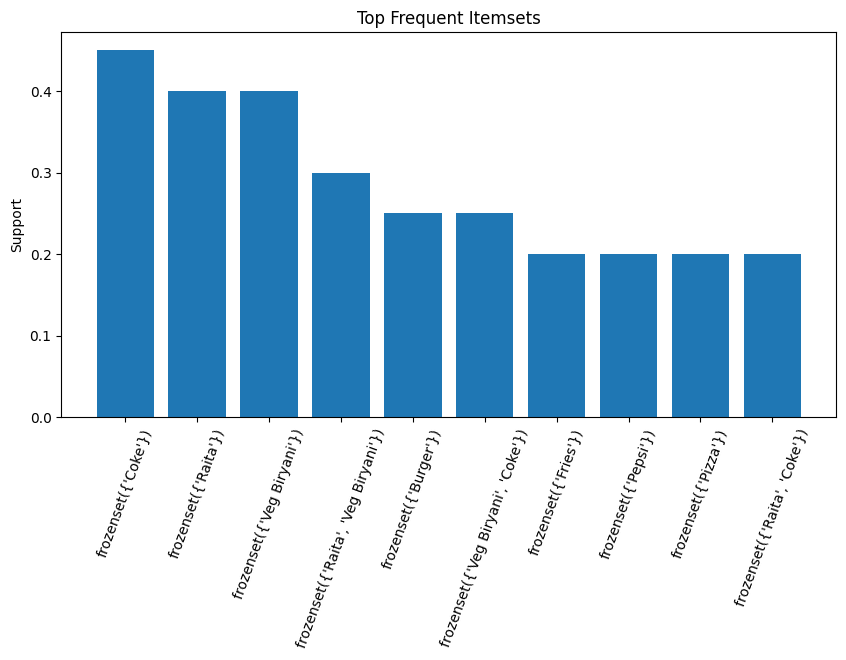

In [23]:
import matplotlib.pyplot as plt

top = frequent_itemsets.copy()

top["Items"] = top["itemsets"].astype(str)

top = top.head(10)

plt.figure(figsize=(10,5))

plt.bar(top["Items"], top["support"])

plt.xticks(rotation=70)

plt.ylabel("Support")

plt.title("Top Frequent Itemsets")

plt.show()

In [24]:
display(
    rules.style
    .background_gradient(cmap="Greens")
    .format({
        "support":"{:.2f}",
        "confidence":"{:.2f}",
        "lift":"{:.2f}"
    })
)

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3811: RuntimeWarning: invalid value encountered in scalar multiply
  norm = _matplotlib.colors.Normalize(smin - (rng * low), smax + (rng * high))


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({'Raita'}),frozenset({'Veg Biryani'}),0.400000,0.400000,0.30,0.75,1.87,1.000000,0.140000,2.400000,0.777778,0.600000,0.583333,0.750000
1,frozenset({'Veg Biryani'}),frozenset({'Raita'}),0.400000,0.400000,0.30,0.75,1.87,1.000000,0.140000,2.400000,0.777778,0.600000,0.583333,0.750000
2,frozenset({'Veg Biryani'}),frozenset({'Coke'}),0.400000,0.450000,0.25,0.62,1.39,1.000000,0.070000,1.466667,0.466667,0.416667,0.318182,0.590278
3,frozenset({'Coke'}),frozenset({'Veg Biryani'}),0.450000,0.400000,0.25,0.56,1.39,1.000000,0.070000,1.350000,0.509091,0.416667,0.259259,0.590278
4,frozenset({'Raita'}),frozenset({'Coke'}),0.400000,0.450000,0.20,0.50,1.11,1.000000,0.020000,1.100000,0.166667,0.307692,0.090909,0.472222
5,frozenset({'Fries'}),frozenset({'Burger'}),0.200000,0.250000,0.20,1.00,4.00,1.000000,0.150000,inf,0.937500,0.800000,1.000000,0.900000
6,frozenset({'Burger'}),frozenset({'Fries'}),0.250000,0.200000,0.20,0.80,4.00,1.000000,0.150000,4.000000,1.000000,0.800000,0.750000,0.900000
